# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
pd.reset_option('display.max_rows')

In [ ]:
path = '/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly' 
files = [
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJan25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataFeb25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMar25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataApr25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMay25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJune25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJan24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataFeb24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMar24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataApr24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMay24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJune24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJuly24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataAug24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataSept24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataOct24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataNov24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataDec24.csv"
]

# read the first file to lock the schema/order
schema = pd.read_csv(files[0], dtype=str, encoding="latin1", low_memory=False).columns.tolist()

def read_and_fix(fp):
    df = pd.read_csv(fp, dtype=str, encoding="latin1", low_memory=False)
    # ensure same columns/order; create missing as NaN, drop extras
    df = df.reindex(columns=schema)

    # --- FIX: rows shifted left from 'freqCode' onward ---
    # Detect: freqCode should be 'M'/'A'/'Q', NOT 8-digit numbers like 20250101
    mask = df["freqCode"].str.fullmatch(r"\d{8}", na=False)
    if mask.any():
        cols = df.columns.tolist()
        j = cols.index("freqCode")

        bad = df.loc[mask, cols].copy()
        # shift right by 1 from freqCode onward
        bad.iloc[:, j+1:] = bad.iloc[:, j:-1].values
        # set correct freqCode
        bad.iloc[:, j] = "M"

        # (Optional) sanity fill for first 6 fields if you want to be extra-safe
        # If refPeriodId is now 8-digit, derive year/month/period just in case
        rpid = bad["refPeriodId"].str.extract(r"(\d{8})", expand=False)
        ok = rpid.notna()
        bad.loc[ok, "refYear"]  = rpid[ok].str.slice(0, 4)
        bad.loc[ok, "refMonth"] = rpid[ok].str.slice(4, 6).astype(int).astype(str)
        bad.loc[ok, "period"]   = (bad.loc[ok, "refYear"].astype(int)*100 + bad.loc[ok, "refMonth"].astype(int)).astype(str)

        df.loc[mask, cols] = bad.values

    return df

dfs = [read_and_fix(f) for f in files]
merged = pd.concat(dfs, ignore_index=True)

# quick sanity check (should show C, M, 8-digit refPeriodId, 4-digit year, 1-12 month, YYYYMM period)
print(merged.iloc[0][["typeCode","freqCode","refPeriodId","refYear","refMonth","period"]])

#merged.to_csv("merged_fixed.csv", index=False, encoding="utf-8")

typeCode              M
freqCode              M
refPeriodId    20250101
refYear            2025
refMonth              1
period           202501
Name: 0, dtype: object


In [9]:
merged

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566738,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,0,false,0,false,25792280.037,NaN,25792280.037,0,false,true
566739,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3,false,0,false,161.41,NaN,161.41,0,false,true
566740,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,2,false,0,false,930.485,NaN,930.485,0,false,true
566741,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3,false,0,false,161.41,NaN,161.41,0,false,true


In [10]:
df = pd.read_csv('merged_fixed.csv', encoding='latin1')
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,1.289771e+03,1.289771e+03,0,False,True
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,2.085918e+03,2.085918e+03,0,False,True
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,2.597565e+10,2.597565e+10,0,False,True
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,3.797100e+02,3.797100e+02,0,False,True
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,9.133,False,NaN,7.397399e+06,7.397399e+06,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566738,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,0.0,False,0.000,False,2.579228e+07,NaN,2.579228e+07,0,False,True
566739,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3.0,False,0.000,False,1.614100e+02,NaN,1.614100e+02,0,False,True
566740,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,2.0,False,0.000,False,9.304850e+02,NaN,9.304850e+02,0,False,True
566741,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3.0,False,0.000,False,1.614100e+02,NaN,1.614100e+02,0,False,True


# Data Understanding

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566743 entries, 0 to 566742
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   typeCode                  566743 non-null  object 
 1   freqCode                  566743 non-null  object 
 2   refPeriodId               566743 non-null  int64  
 3   refYear                   566743 non-null  int64  
 4   refMonth                  566743 non-null  int64  
 5   period                    566743 non-null  int64  
 6   reporterCode              566743 non-null  int64  
 7   reporterISO               566743 non-null  object 
 8   reporterDesc              566743 non-null  object 
 9   flowCode                  566743 non-null  object 
 10  flowDesc                  566743 non-null  object 
 11  partnerCode               566743 non-null  int64  
 12  partnerISO                566743 non-null  object 
 13  partnerDesc               566743 non-null  o

We have 47 tables, but not all of them is useful

In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 7 unique values
refYear: 1 unique values
refMonth: 7 unique values
period: 7 unique values
reporterCode: 75 unique values
reporterISO: 75 unique values
reporterDesc: 75 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 244 unique values
partnerISO: 243 unique values
partnerDesc: 244 unique values
partner2Code: 241 unique values
partner2ISO: 241 unique values
partner2Desc: 241 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 2 unique values
cmdDesc: 2 unique values
aggrLevel: 2 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 10007 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQtyUnitAb

In [13]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['M']
1
----------------------------------------
Column: freqCode
['M']
1
----------------------------------------
Column: refPeriodId
[20250101 20250201 20250301 20250401 20250501 20250601 20250701]
7
----------------------------------------
Column: refYear
[2025]
1
----------------------------------------
Column: refMonth
[1 2 3 4 5 6 7]
7
----------------------------------------
Column: period
[202501 202502 202503 202504 202505 202506 202507]
7
----------------------------------------
Column: reporterCode
[ 36 100  70  76  51  56  32  31  84  28  52  68 191 208 124 203 152 246
 234 268 233 222 242 276 300 328 344 308 320 442 428 392 458 480 440 348
 372 380 484 417 352 376 446 498 604 682 586 616 566 620 642 528 516 554
 579 499 591 608 600 504 705 703 688 699 710 716 724 752 757 764 768 792
 804 826 842]
75
----------------------------------------
Column: reporterISO
['AUS' 'BGR' 'BIH' 'BRA' 'ARM' 'BEL' 'ARG' 'AZE' 'BLZ' 'ATG' 'BRB' 'BOL'
 'HRV' 'DNK' 'CAN' 'CZE' 

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [14]:
df_copy = df.copy()

In [15]:
df_copy

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,1.289771e+03,1.289771e+03,0,False,True
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,2.085918e+03,2.085918e+03,0,False,True
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,2.597565e+10,2.597565e+10,0,False,True
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,0.000,False,NaN,3.797100e+02,3.797100e+02,0,False,True
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,False,9.133,False,NaN,7.397399e+06,7.397399e+06,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566738,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,0.0,False,0.000,False,2.579228e+07,NaN,2.579228e+07,0,False,True
566739,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3.0,False,0.000,False,1.614100e+02,NaN,1.614100e+02,0,False,True
566740,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,2.0,False,0.000,False,9.304850e+02,NaN,9.304850e+02,0,False,True
566741,M,M,20250701,2025,7,202507,579,NOR,Norway,M,...,3.0,False,0.000,False,1.614100e+02,NaN,1.614100e+02,0,False,True


In [16]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'refMonth', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'qty', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt', 'primaryValue'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),1,X,Export,TOTAL,All Commodities,0.0,1.289771e+03,NaN,NaN,0.000,1.289771e+03
1,36,Australia,84,Belize,1,X,Export,TOTAL,All Commodities,0.0,2.085918e+03,NaN,NaN,0.000,2.085918e+03
2,36,Australia,0,World,1,X,Export,TOTAL,All Commodities,0.0,2.597565e+10,NaN,NaN,0.000,2.597565e+10
3,36,Australia,140,Central African Rep.,1,X,Export,TOTAL,All Commodities,0.0,3.797100e+02,NaN,NaN,0.000,3.797100e+02
4,36,Australia,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,7.397399e+06,NaN,NaN,9.133,7.397399e+06


In [17]:
# Split export data
df_copy_export = df_copy[df_copy['flowDesc'] == 'Export']

# Split import data
df_copy_import = df_copy[df_copy['flowDesc'] == 'Import']


In [18]:
df_copy_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),1,X,Export,TOTAL,All Commodities,0.0,1.289771e+03,NaN,NaN,0.000,1.289771e+03
1,36,Australia,84,Belize,1,X,Export,TOTAL,All Commodities,0.0,2.085918e+03,NaN,NaN,0.000,2.085918e+03
2,36,Australia,0,World,1,X,Export,TOTAL,All Commodities,0.0,2.597565e+10,NaN,NaN,0.000,2.597565e+10
3,36,Australia,140,Central African Rep.,1,X,Export,TOTAL,All Commodities,0.0,3.797100e+02,NaN,NaN,0.000,3.797100e+02
4,36,Australia,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,7.397399e+06,NaN,NaN,9.133,7.397399e+06


In [19]:
df_copy_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
231,36,Australia,703,Slovakia,1,M,Import,8542,Electronic integrated circuits,5389.0,9306.847,9385.708,5.744,0.004,9385.708
232,36,Australia,56,Belgium,1,M,Import,8542,Electronic integrated circuits,4.0,666.323,725.776,0.390,0.001,725.776
233,36,Australia,504,Morocco,1,M,Import,8542,Electronic integrated circuits,25025.0,8280.091,8568.740,5.062,0.000,8568.740
234,36,Australia,372,Ireland,1,M,Import,8542,Electronic integrated circuits,20.0,1637.654,1736.472,0.934,0.000,1736.472
235,36,Australia,710,South Africa,1,M,Import,8542,Electronic integrated circuits,60.0,1993.038,2012.715,1.232,0.000,2012.715


# Data Cleaning (Handling Missing Values)

## Export

In [20]:
df_copy_export.describe()

,reporterCode,partnerCode,refMonth,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,140293.000000,140293.000000,140293.000000,1.402930e+05,1.402930e+05,0.0,1.351380e+05,1.402930e+05,1.402930e+05
mean,499.992972,405.231252,3.299580,1.164510e+04,1.191526e+08,NaN,1.455430e+03,9.069777e+01,1.191526e+08
std,226.241243,265.239882,1.660059,6.805489e+05,1.962303e+09,NaN,6.608977e+04,8.114110e+03,1.962303e+09
min,28.000000,0.000000,1.000000,0.000000e+00,1.000000e-03,NaN,0.000000e+00,0.000000e+00,1.000000e-03
25%,276.000000,191.000000,2.000000,0.000000e+00,1.024733e+04,NaN,0.000000e+00,0.000000e+00,1.024733e+04
50%,600.000000,398.000000,3.000000,0.000000e+00,2.078400e+05,NaN,0.000000e+00,0.000000e+00,2.078400e+05
75%,642.000000,642.000000,5.000000,0.000000e+00,4.109877e+06,NaN,0.000000e+00,0.000000e+00,4.109877e+06
max,842.000000,899.000000,7.000000,1.559534e+08,1.829220e+11,NaN,1.146016e+07,1.518068e+06,1.829220e+11


In [21]:
df_copy_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140293 entries, 0 to 563537
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  140293 non-null  int64  
 1   reporterDesc  140293 non-null  object 
 2   partnerCode   140293 non-null  int64  
 3   partnerDesc   140293 non-null  object 
 4   refMonth      140293 non-null  int64  
 5   flowCode      140293 non-null  object 
 6   flowDesc      140293 non-null  object 
 7   cmdCode       140293 non-null  object 
 8   cmdDesc       140293 non-null  object 
 9   qty           140293 non-null  float64
 10  fobvalue      140293 non-null  float64
 11  cifvalue      0 non-null       float64
 12  netWgt        135138 non-null  float64
 13  grossWgt      140293 non-null  float64
 14  primaryValue  140293 non-null  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 17.1+ MB


In [22]:
df_copy_export.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue             0
cifvalue        140293
netWgt            5155
grossWgt             0
primaryValue         0
dtype: int64

In [23]:
df_copy_export[df_copy_export.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),1,X,Export,TOTAL,All Commodities,0.0,1.289771e+03,NaN,NaN,0.000,1.289771e+03
1,36,Australia,84,Belize,1,X,Export,TOTAL,All Commodities,0.0,2.085918e+03,NaN,NaN,0.000,2.085918e+03
2,36,Australia,0,World,1,X,Export,TOTAL,All Commodities,0.0,2.597565e+10,NaN,NaN,0.000,2.597565e+10
3,36,Australia,140,Central African Rep.,1,X,Export,TOTAL,All Commodities,0.0,3.797100e+02,NaN,NaN,0.000,3.797100e+02
4,36,Australia,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,7.397399e+06,NaN,NaN,9.133,7.397399e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563533,579,Norway,591,Panama,7,X,Export,TOTAL,All Commodities,0.0,5.433277e+05,NaN,0.0,0.000,5.433277e+05
563534,579,Norway,834,United Rep. of Tanzania,7,X,Export,TOTAL,All Commodities,0.0,6.506389e+05,NaN,0.0,0.000,6.506389e+05
563535,579,Norway,768,Togo,7,X,Export,TOTAL,All Commodities,0.0,2.370241e+05,NaN,0.0,0.000,2.370241e+05
563536,579,Norway,780,Trinidad and Tobago,7,X,Export,TOTAL,All Commodities,0.0,4.381695e+05,NaN,0.0,0.000,4.381695e+05


In [24]:
check = df_copy_export[df_copy_export['netWgt'].isna()]
check.sample(10)

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
463545,554,New Zealand,392,Japan,5,X,Export,8542,Electronic integrated circuits,1.0,2.900015e+03,NaN,NaN,2.000,2.900015e+03
512138,124,Canada,316,Guam,6,X,Export,TOTAL,All Commodities,0.0,2.588090e+05,NaN,NaN,0.000,2.588090e+05
244359,392,Japan,807,North Macedonia,3,X,Export,8542,Electronic integrated circuits,48400.0,3.446955e+04,NaN,NaN,0.000,3.446955e+04
374541,699,India,716,Zimbabwe,4,X,Export,8542,Electronic integrated circuits,10.0,1.779695e+03,NaN,NaN,0.000,1.779695e+03
560072,792,TÃ¼rkiye,0,World,6,X,Export,TOTAL,All Commodities,0.0,2.051539e+10,NaN,NaN,0.000,2.051539e+10
310406,203,Czechia,442,Luxembourg,4,X,Export,TOTAL,All Commodities,0.0,3.610184e+07,NaN,NaN,0.000,3.610184e+07
126079,268,Georgia,434,Libya,2,X,Export,TOTAL,All Commodities,0.0,6.590435e+05,NaN,NaN,0.000,6.590435e+05
357575,642,Romania,348,Hungary,4,X,Export,TOTAL,All Commodities,0.0,2.913341e+05,NaN,NaN,0.000,2.913341e+05
272582,554,New Zealand,184,Cook Isds,3,X,Export,8542,Electronic integrated circuits,0.0,1.220149e+04,NaN,NaN,5.000,1.220149e+04
200231,36,Australia,124,Canada,3,X,Export,8542,Electronic integrated circuits,2.0,7.638150e+02,NaN,NaN,0.001,7.638150e+02


In [25]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy_export.isna().mean() * 100
print(percent_missing)

reporterCode      0.000000
reporterDesc      0.000000
partnerCode       0.000000
partnerDesc       0.000000
refMonth          0.000000
flowCode          0.000000
flowDesc          0.000000
cmdCode           0.000000
cmdDesc           0.000000
qty               0.000000
fobvalue          0.000000
cifvalue        100.000000
netWgt            3.674453
grossWgt          0.000000
primaryValue      0.000000
dtype: float64


we don't need 'cifvalue' in here. ('fobvalue' is a cost of goods at point of export, while 'cifvalue' is a shipping/import costs).

In [26]:
# Check for zero values in selected columns of df_copy_export
zero_counts = df_copy_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode         0
reporterDesc         0
partnerCode       9905
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty             133539
fobvalue             0
cifvalue             0
netWgt          115875
grossWgt        139654
primaryValue         0
dtype: int64


In [34]:
# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_export['netWgt'].mean()
df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2338780976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2338780976.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)


In [35]:
df_export = df_copy_export.drop(columns=['cifvalue'])

In [36]:
# check again
percent_missing_check = df_export.isna().mean() * 100
percent_missing_check

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
refMonth        0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
qty             0.0
fobvalue        0.0
netWgt          0.0
grossWgt        0.0
primaryValue    0.0
dtype: float64

In [37]:
#check again
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode         0
reporterDesc         0
partnerCode       9905
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty             133539
fobvalue             0
netWgt               0
grossWgt        139654
primaryValue         0
dtype: int64


Since we use 'netWgt' the most, we will drop the 'grossWgt' and 'primaryvalue'

In [38]:
df_export.drop(columns=['grossWgt', 'primaryValue'], inplace=True)

In [39]:
df_export = df_export.reset_index(drop=True)
df_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),1,X,Export,TOTAL,All Commodities,0.0,1.289771e+03,1401.950976
1,36,Australia,84,Belize,1,X,Export,TOTAL,All Commodities,0.0,2.085918e+03,1401.950976
2,36,Australia,0,World,1,X,Export,TOTAL,All Commodities,0.0,2.597565e+10,1401.950976
3,36,Australia,140,Central African Rep.,1,X,Export,TOTAL,All Commodities,0.0,3.797100e+02,1401.950976
4,36,Australia,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,7.397399e+06,1401.950976


In [40]:
# Check rows where reporterCode is 0 in the check DataFrame
df_export[df_export['partnerCode'] == 0]

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
2,36,Australia,0,World,1,X,Export,TOTAL,All Commodities,0.0,2.597565e+10,1401.950976
4,36,Australia,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,7.397399e+06,1401.950976
457,100,Bulgaria,0,World,1,X,Export,8542,Electronic integrated circuits,0.0,4.031814e+07,80758.122000
458,100,Bulgaria,0,World,1,X,Export,TOTAL,All Commodities,0.0,3.336650e+09,1401.950976
465,70,Bosnia Herzegovina,0,World,1,X,Export,TOTAL,All Commodities,0.0,6.451743e+08,1401.950976
...,...,...,...,...,...,...,...,...,...,...,...,...
139737,579,Norway,0,World,7,X,Export,TOTAL,All Commodities,0.0,9.063452e+06,1401.950976
139738,579,Norway,0,World,7,X,Export,TOTAL,All Commodities,0.0,1.096869e+05,1401.950976
139739,579,Norway,0,World,7,X,Export,TOTAL,All Commodities,0.0,7.397522e+07,1401.950976
139740,579,Norway,0,World,7,X,Export,TOTAL,All Commodities,0.0,1.434322e+05,1401.950976


In [41]:
partner_counts = df_export['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
partner_counts

,Country,Count
0,World,9905
1,Germany,2418
2,Italy,2229
3,Spain,2227
4,France,2147
...,...,...
239,"Oceania, nes",15
240,South Georgia and the South Sandwich Islands,10
241,Free Zones,8
242,"Rest of America, nes",5


In [87]:
df_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140293 entries, 0 to 140292
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  140293 non-null  int64  
 1   reporterDesc  140293 non-null  object 
 2   partnerCode   140293 non-null  int64  
 3   partnerDesc   140293 non-null  object 
 4   refMonth      140293 non-null  int64  
 5   flowCode      140293 non-null  object 
 6   flowDesc      140293 non-null  object 
 7   cmdCode       140293 non-null  object 
 8   cmdDesc       140293 non-null  object 
 9   qty           140293 non-null  float64
 10  fobvalue      140293 non-null  float64
 11  netWgt        140293 non-null  float64
 12  value_per_kg  140293 non-null  float64
dtypes: float64(4), int64(3), object(6)
memory usage: 13.9+ MB


## Import (In case we need it)

In [42]:
df_copy_import.describe()

,reporterCode,partnerCode,refMonth,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,426450.000000,426450.000000,426450.000000,4.264500e+05,1.599960e+05,3.998650e+05,4.154060e+05,426450.000000,4.264500e+05
mean,454.727612,421.958778,3.383107,2.366489e+04,3.184871e+07,4.046860e+07,7.994725e+02,21.233779,4.213283e+07
std,250.366876,265.388915,1.659999,1.204771e+06,1.147067e+09,1.050662e+09,4.345777e+04,3286.947691,1.062992e+09
min,28.000000,0.000000,1.000000,0.000000e+00,3.000000e-02,1.100000e-02,0.000000e+00,0.000000,1.100000e-02
25%,233.000000,191.000000,2.000000,0.000000e+00,1.527000e+03,1.843570e+03,0.000000e+00,0.000000,1.892729e+03
50%,498.000000,410.000000,3.000000,0.000000e+00,2.551224e+04,3.359400e+04,0.000000e+00,0.000000,3.401685e+04
75%,699.000000,688.000000,5.000000,0.000000e+00,3.797575e+05,5.361708e+05,0.000000e+00,0.000000,5.455368e+05
max,842.000000,899.000000,7.000000,3.943494e+08,2.763417e+11,2.836807e+11,1.577252e+07,953573.960000,2.836807e+11


In [43]:
df_copy_import.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426450 entries, 231 to 566742
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  426450 non-null  int64  
 1   reporterDesc  426450 non-null  object 
 2   partnerCode   426450 non-null  int64  
 3   partnerDesc   426450 non-null  object 
 4   refMonth      426450 non-null  int64  
 5   flowCode      426450 non-null  object 
 6   flowDesc      426450 non-null  object 
 7   cmdCode       426450 non-null  object 
 8   cmdDesc       426450 non-null  object 
 9   qty           426450 non-null  float64
 10  fobvalue      159996 non-null  float64
 11  cifvalue      399865 non-null  float64
 12  netWgt        415406 non-null  float64
 13  grossWgt      426450 non-null  float64
 14  primaryValue  426450 non-null  float64
dtypes: float64(6), int64(3), object(6)
memory usage: 52.1+ MB


In [44]:
df_copy_import.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue        266454
cifvalue         26585
netWgt           11044
grossWgt             0
primaryValue         0
dtype: int64

In [45]:
# Check for zero values in selected columns of df_copy_import
zero_counts = df_copy_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode         0
reporterDesc         0
partnerCode      24459
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty             412362
fobvalue             0
cifvalue             0
netWgt          369704
grossWgt        425845
primaryValue         0
dtype: int64


In [46]:
# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_import['netWgt'].mean()
df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2157446826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2157446826.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)


In [47]:
median_cifvalue = df_copy_import['cifvalue'].median()
df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/1152221904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)


In [48]:
df_import = df_copy_import.drop(columns=['fobvalue', 'grossWgt', 'primaryValue'])

In [49]:
# check again
percent_missing_check = df_import.isna().mean() * 100
percent_missing_check

reporterCode    0.000000
reporterDesc    0.000000
partnerCode     0.000000
partnerDesc     0.000000
refMonth        0.000000
flowCode        0.000000
flowDesc        0.000000
cmdCode         0.000000
cmdDesc         0.000000
qty             0.000000
cifvalue        6.234025
netWgt          0.000000
dtype: float64

In [50]:
#check again
zero_counts = df_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode         0
reporterDesc         0
partnerCode      24459
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty             412362
cifvalue             0
netWgt               0
dtype: int64


In [51]:
df_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,cifvalue,netWgt
231,36,Australia,703,Slovakia,1,M,Import,8542,Electronic integrated circuits,5389.0,9385.708,5.744
232,36,Australia,56,Belgium,1,M,Import,8542,Electronic integrated circuits,4.0,725.776,0.390
233,36,Australia,504,Morocco,1,M,Import,8542,Electronic integrated circuits,25025.0,8568.740,5.062
234,36,Australia,372,Ireland,1,M,Import,8542,Electronic integrated circuits,20.0,1736.472,0.934
235,36,Australia,710,South Africa,1,M,Import,8542,Electronic integrated circuits,60.0,2012.715,1.232


In [52]:
partner_counts = df_import['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
total = partner_counts['Count'].sum()
print(f"Total: {total}")
partner_counts

Total: 426450


,Country,Count
0,World,24459
1,China,12285
2,USA,9621
3,Germany,7926
4,"Other Asia, nes",7403
...,...,...
238,South Georgia and the South Sandwich Islands,48
239,Heard Island and McDonald Islands,24
240,Bunkers,22
241,"Oceania, nes",18


## Unique Findings !!
#### Exporters

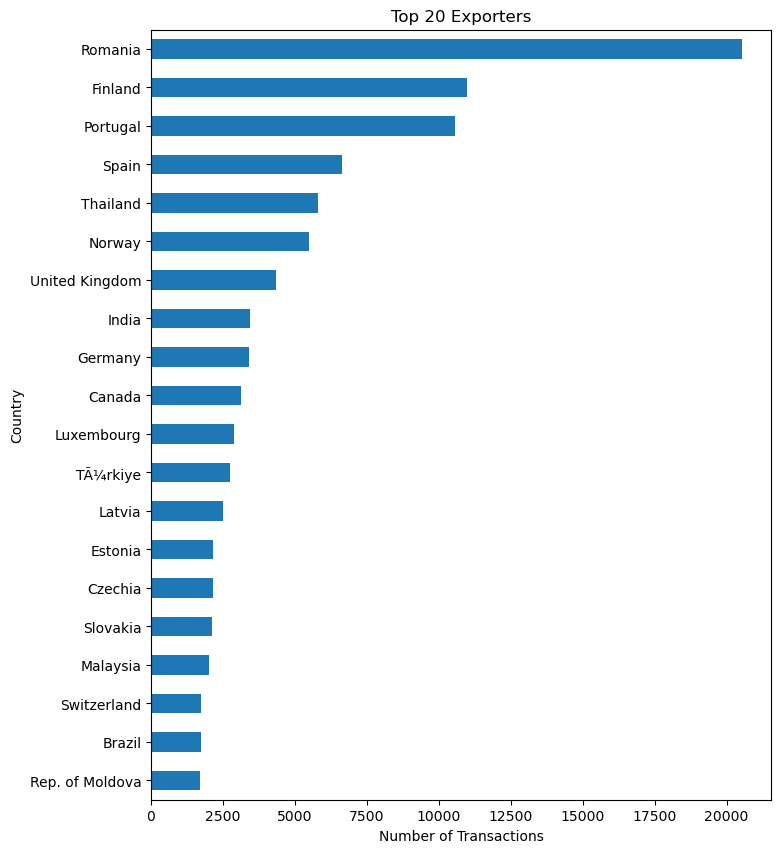

In [54]:
# From df_export
df_export['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Exporters")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

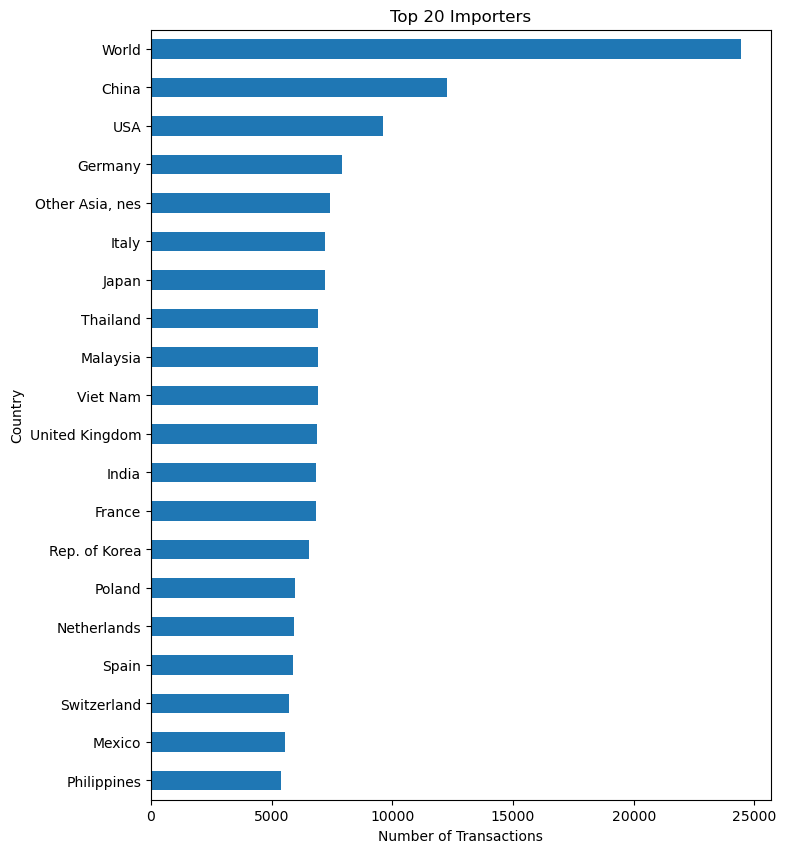

In [56]:
# From df_import
df_import['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Importers

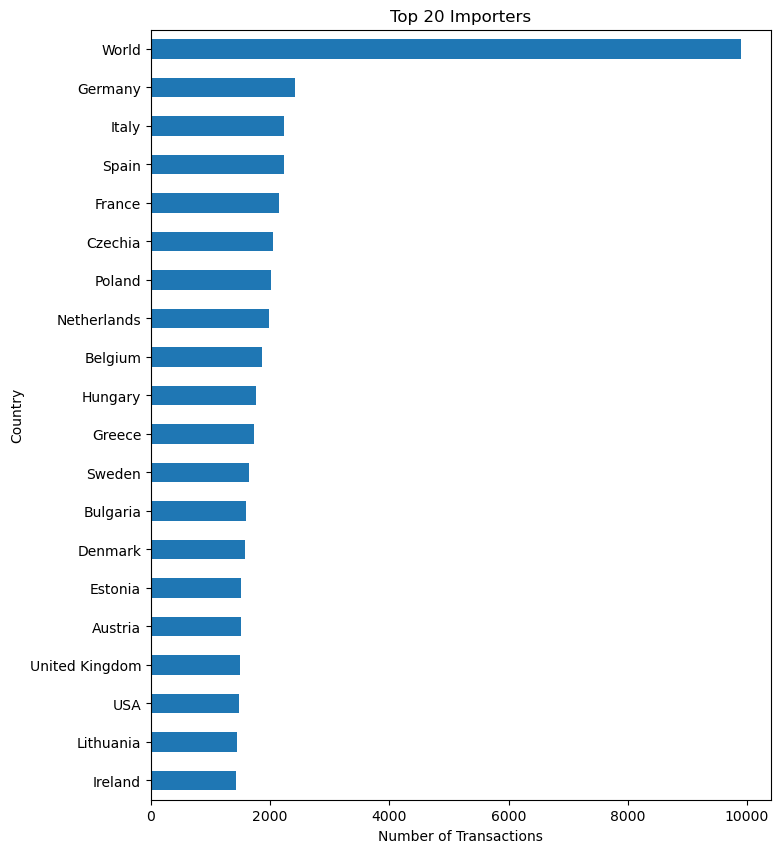

In [57]:
# From df_export
df_export['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

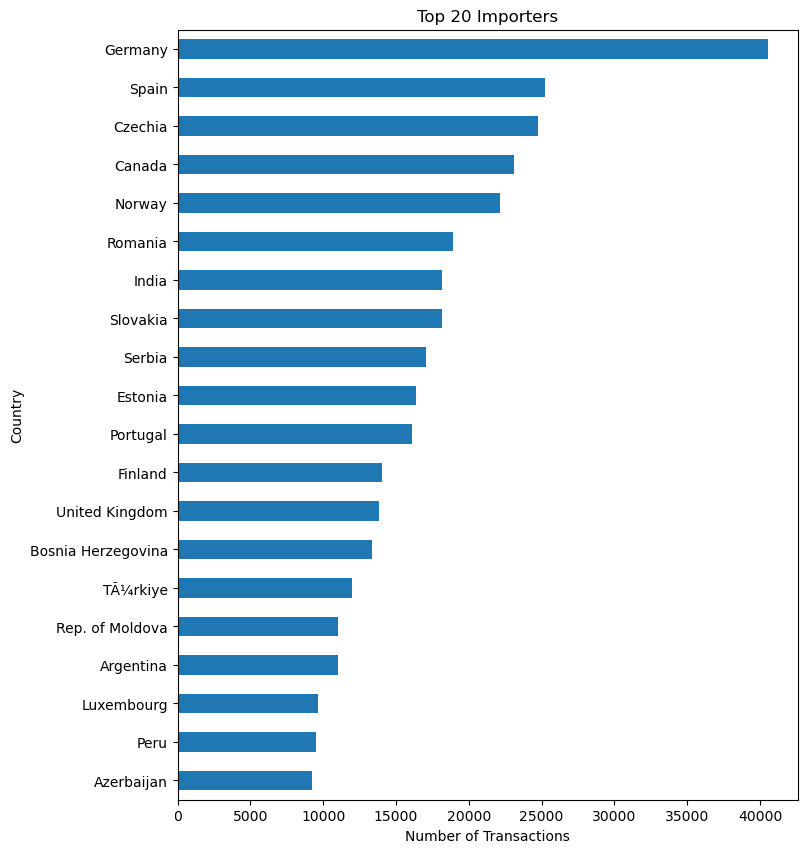

In [58]:
# From df_import
df_import['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Insight:
We can take a data either import or export from both export report or import report. However, we will have some aggregation data from the opposite report such as taking an export data from import report which exporter will be as 'partner' and the 'reporter' will be the import country. The reporter somehow create a aggregation data such as 'World' as their 'partner'. So we have to focus on the 'reporter' only to avoid aggregation data.

# Outlier Check

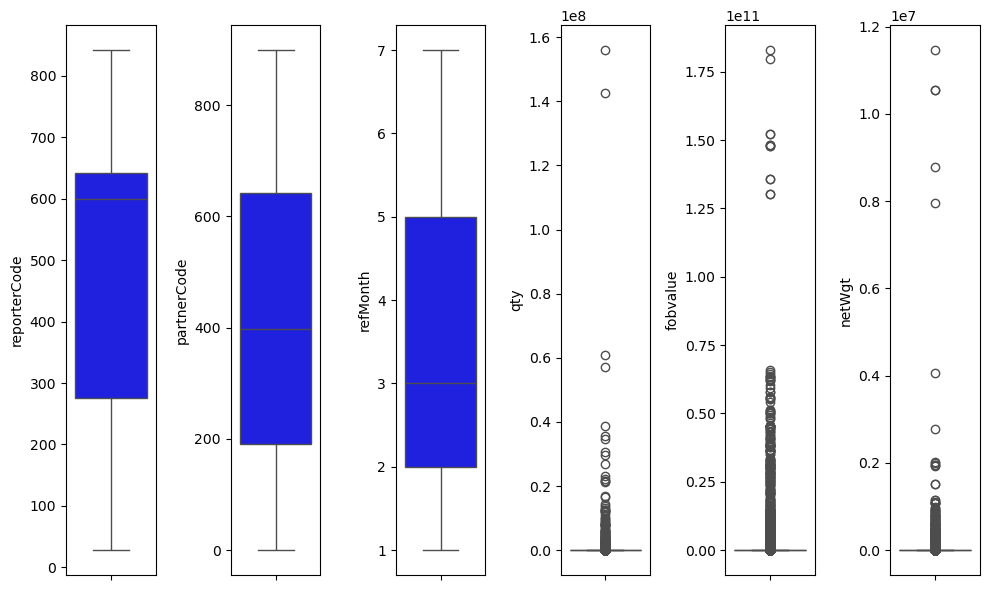

In [59]:
# Check outliers
numerical_columns = df_export.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_export[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Export Data for PBI uses

In [ ]:
df_export.to_excel('df_export.xlsx', index=False)

In [ ]:
df_import.to_excel('df_import.xlsx', index=False)

## Data of the quantity

In [60]:
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode         0
reporterDesc         0
partnerCode       9905
partnerDesc          0
refMonth             0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty             133539
fobvalue             0
netWgt               0
dtype: int64


In [61]:
# Drop rows where 'qty' is zero in df_export
df_export_qty = df_export[df_export['qty'] != 0].reset_index(drop=True)
df_export_qty.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,refMonth,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,166,Cocos Isds,1,X,Export,8542,Electronic integrated circuits,1.0,12449.524,1401.950976
1,36,Australia,162,Christmas Isds,1,X,Export,8542,Electronic integrated circuits,1.0,12449.524,1401.950976
2,36,Australia,608,Philippines,1,X,Export,8542,Electronic integrated circuits,1.0,2161.237,1401.950976
3,36,Australia,854,Burkina Faso,1,X,Export,8542,Electronic integrated circuits,1.0,1285.413,1401.950976
4,36,Australia,348,Hungary,1,X,Export,8542,Electronic integrated circuits,1.0,518.523,1401.950976


In [62]:
zero_counts = df_export_qty.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode      0
reporterDesc      0
partnerCode     540
partnerDesc       0
refMonth          0
flowCode          0
flowDesc          0
cmdCode           0
cmdDesc           0
qty               0
fobvalue          0
netWgt            0
dtype: int64


In [63]:
df_export_qty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6754 entries, 0 to 6753
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   reporterCode  6754 non-null   int64  
 1   reporterDesc  6754 non-null   object 
 2   partnerCode   6754 non-null   int64  
 3   partnerDesc   6754 non-null   object 
 4   refMonth      6754 non-null   int64  
 5   flowCode      6754 non-null   object 
 6   flowDesc      6754 non-null   object 
 7   cmdCode       6754 non-null   object 
 8   cmdDesc       6754 non-null   object 
 9   qty           6754 non-null   float64
 10  fobvalue      6754 non-null   float64
 11  netWgt        6754 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 633.3+ KB


In [64]:
df_export_qty.to_excel('df_export_qty.xlsx', index=False)

# Data Manipulation

In [65]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_export.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,reporterCode,partnerCode,refMonth,qty,fobvalue,netWgt
0,36,238,1,0.0,1.289771e+03,1401.950976
1,36,84,1,0.0,2.085918e+03,1401.950976
2,36,0,1,0.0,2.597565e+10,1401.950976
3,36,140,1,0.0,3.797100e+02,1401.950976
4,36,0,1,0.0,7.397399e+06,1401.950976


In [66]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

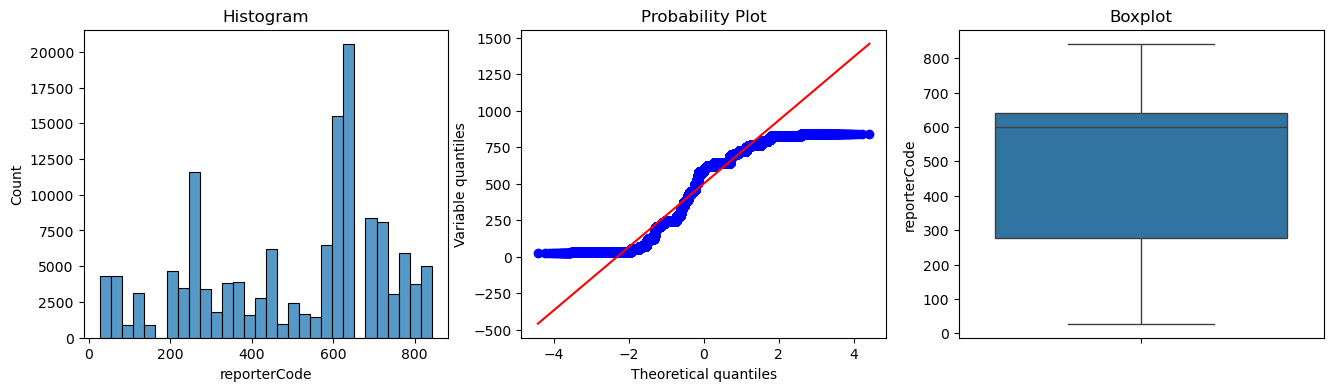

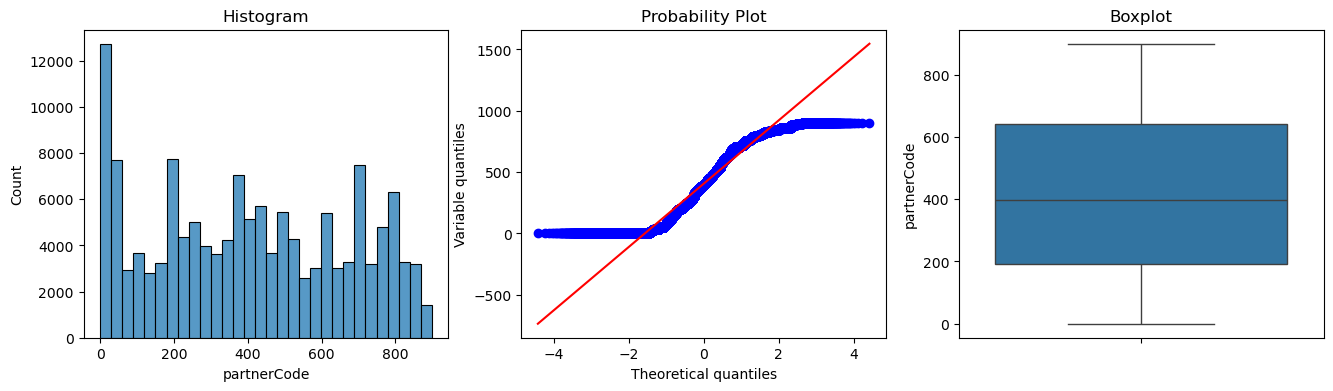

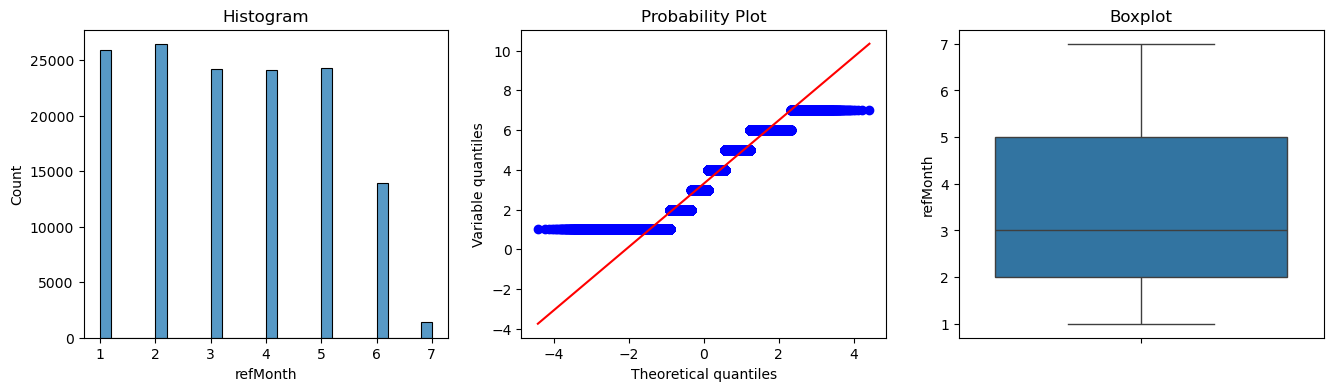

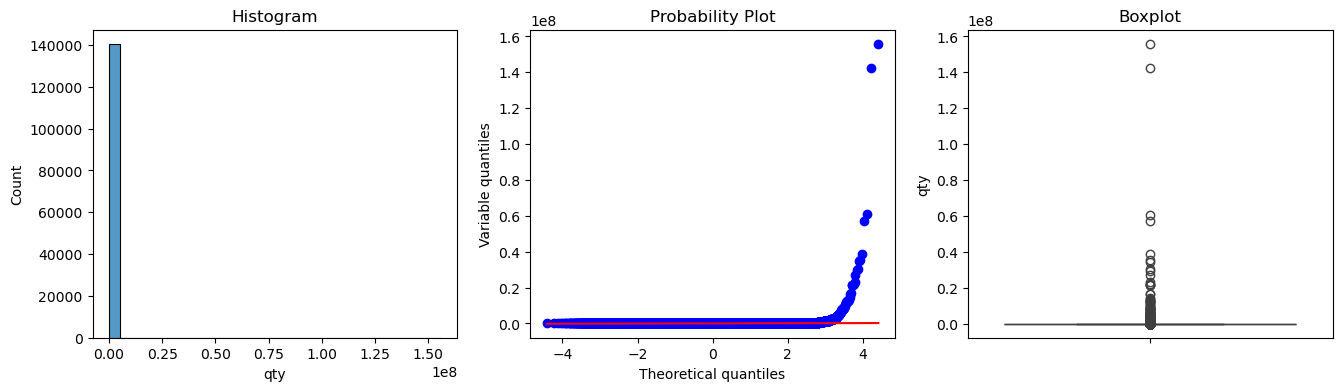

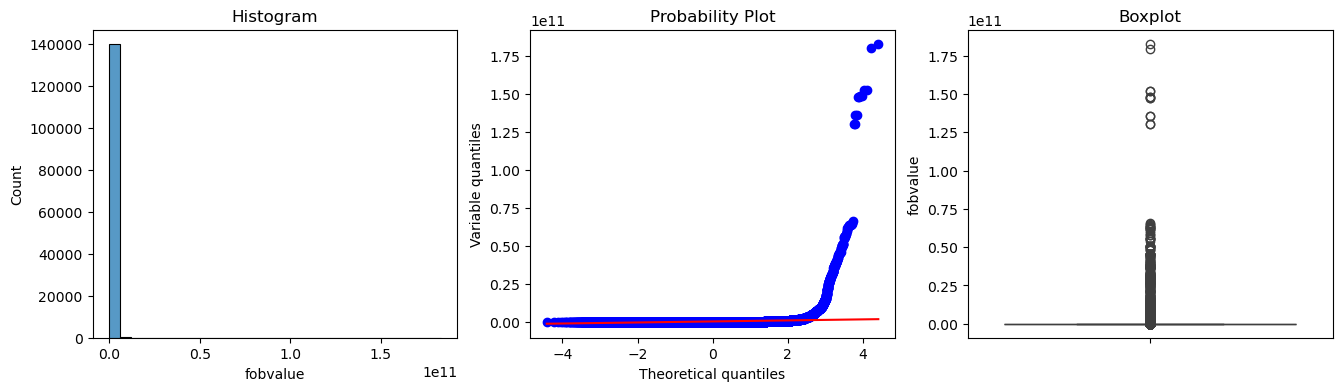

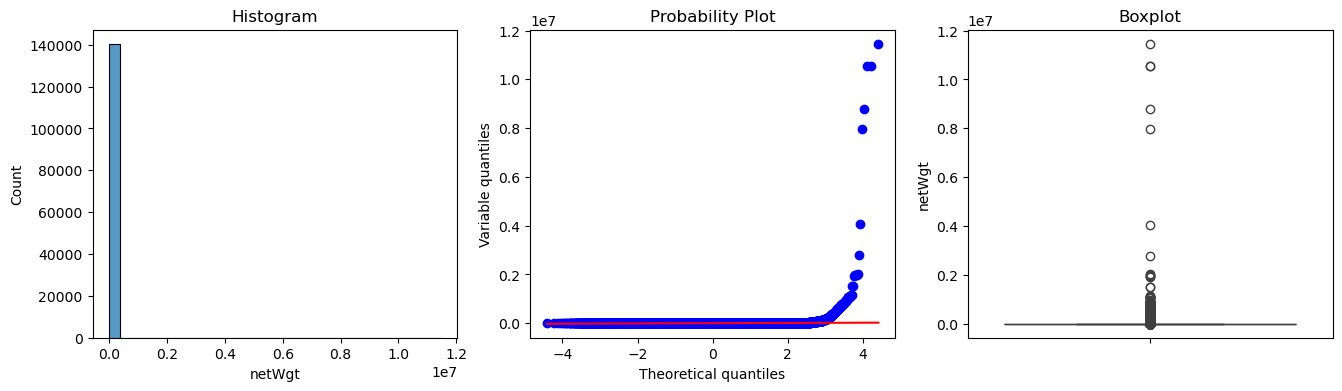

In [67]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [68]:
top_countries = df_export.groupby('reporterDesc')['fobvalue'].sum().sort_values(ascending=False).reset_index()
top_countries.head(10)

,reporterDesc,fobvalue
0,Germany,2.889185e+12
1,Canada,1.122910e+12
2,India,9.089041e+11
3,Spain,8.668243e+11
4,"China, Hong Kong SAR",7.866483e+11
5,Japan,7.507147e+11
6,USA,7.425188e+11
7,Netherlands,6.125583e+11
8,Italy,5.822112e+11
9,Switzerland,5.539933e+11


/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/1022818561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')


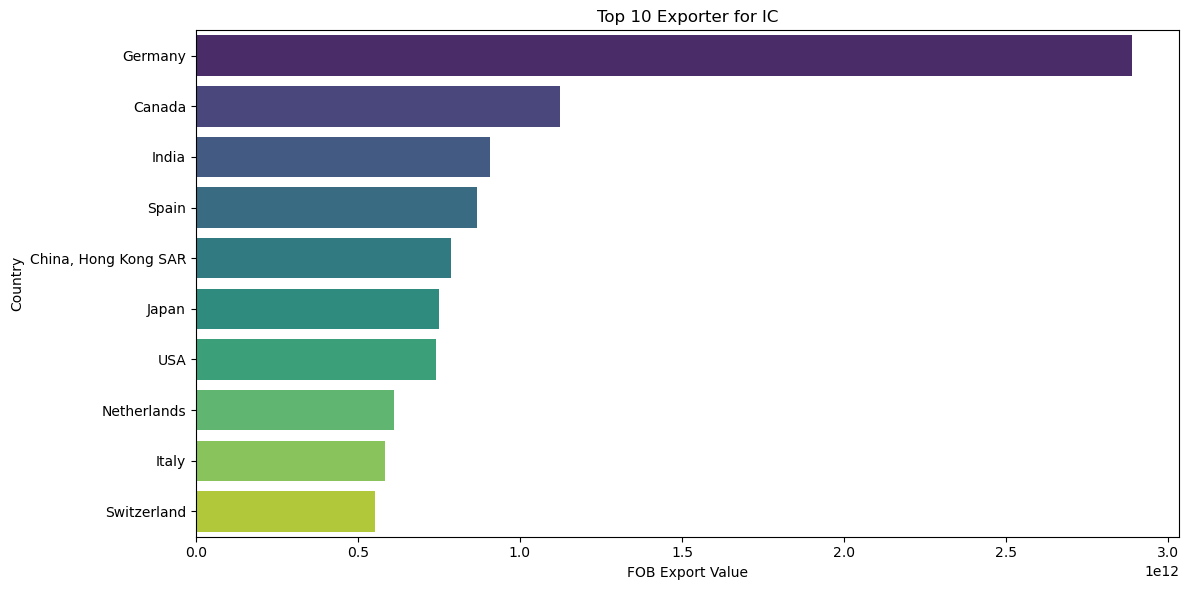

In [69]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')
plt.title('Top 10 Exporter for IC')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='refMonth'>

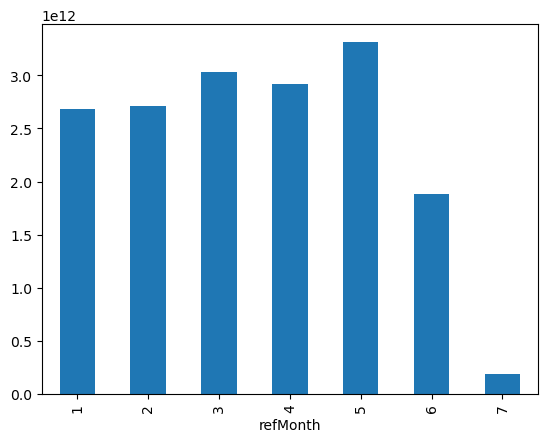

In [88]:
df_export.groupby(['refMonth'])['fobvalue'].sum().plot(kind='bar')

In [89]:
# a. Trend analysis over time
trend_df = df_export.groupby("refMonth")["fobvalue"].sum().reset_index()
trend_df

,refMonth,fobvalue
0,1,2.680988e+12
1,2,2.708961e+12
2,3,3.031402e+12
3,4,2.914110e+12
4,5,3.315628e+12
5,6,1.877979e+12
6,7,1.872109e+11


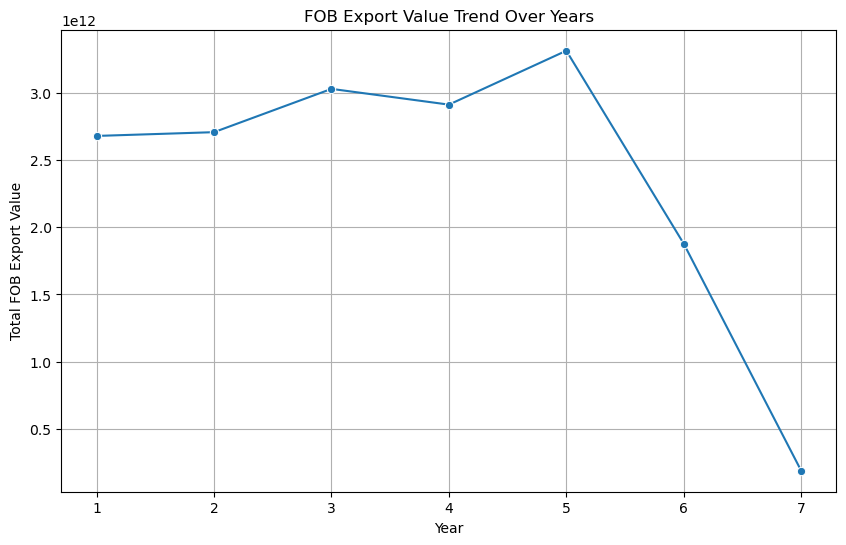

In [74]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='refMonth', y='fobvalue', marker='o')
plt.title('FOB Export Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total FOB Export Value')
plt.grid(True)
plt.show()

In [75]:
# Calculate export value per kg
df_export["value_per_kg"] = df_export["fobvalue"] / df_export["netWgt"]

In [76]:
# b. Avg export value/kg by country
value_per_kg_df = df_export.groupby("reporterDesc")["value_per_kg"].mean().reset_index()
value_per_kg_df = value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)
value_per_kg_df

,reporterDesc,value_per_kg
71,USA,809835.631091
25,Germany,598375.190009
43,Mexico,536645.204300
14,"China, Hong Kong SAR",332617.697718
36,Japan,332284.141756
35,Italy,277030.848979
47,Netherlands,266332.533522
12,Canada,257213.398388
67,Switzerland,227667.996132
60,Saudi Arabia,226164.937996


/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/769833094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


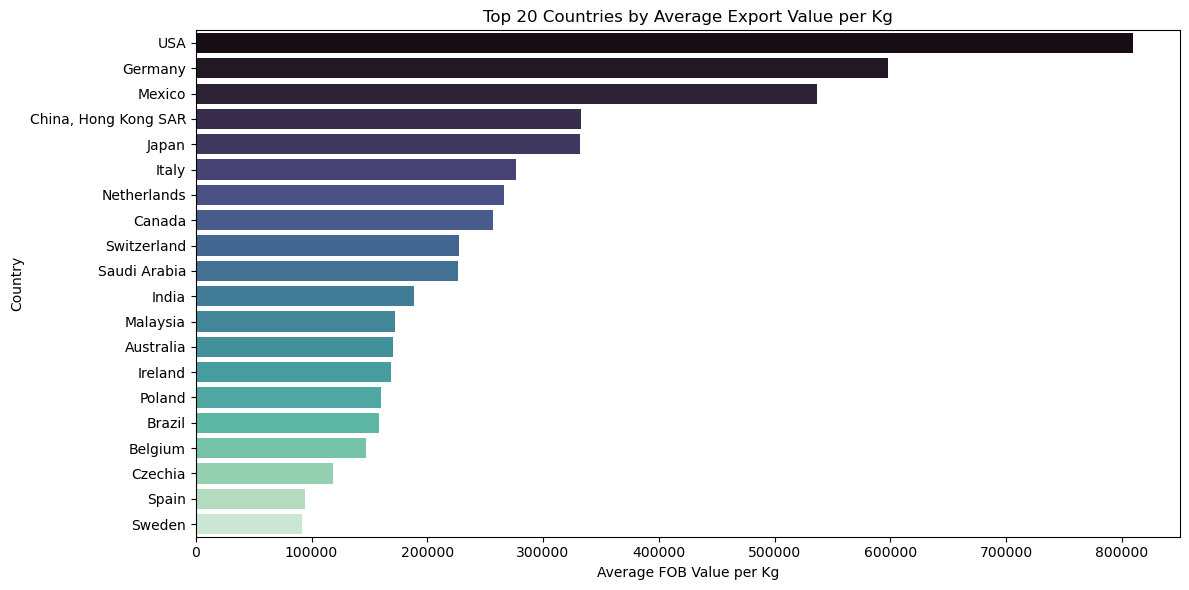

In [77]:
plt.figure(figsize=(12, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [78]:
importer_value_per_kg_df = df_export.groupby("partnerDesc").agg(
    total_fobvalue=("fobvalue", "sum"),
    total_netwgt=("netWgt", "sum")
).reset_index()

In [79]:
# Calculate value per kg
importer_value_per_kg_df["value_per_kg"] = (
    importer_value_per_kg_df["total_fobvalue"] / importer_value_per_kg_df["total_netwgt"]
)
importer_value_per_kg_df = importer_value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)


/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/491785898.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/491785898.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')


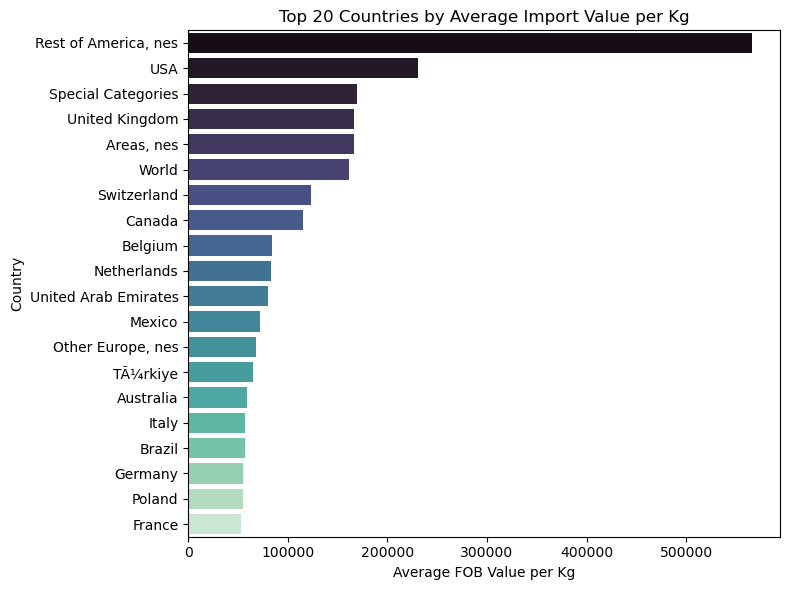

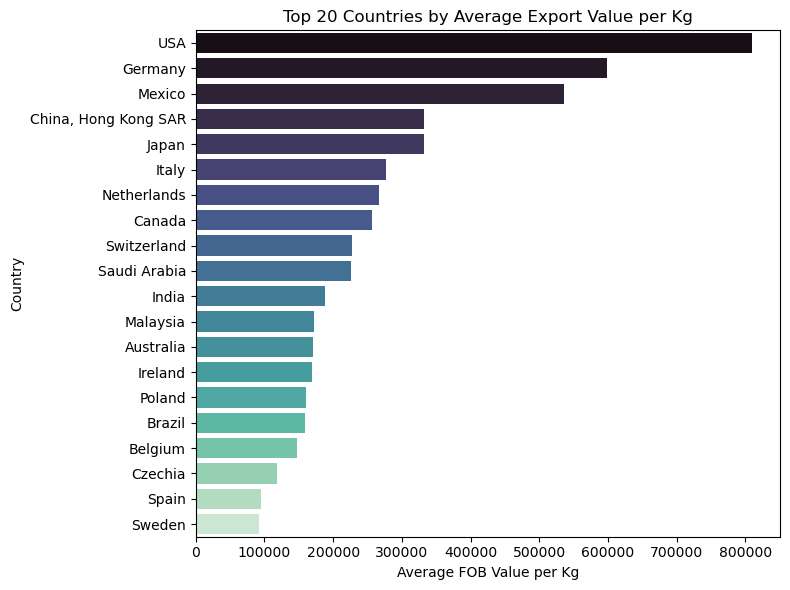

In [80]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
plt.title('Top 20 Countries by Average Import Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/101735088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")


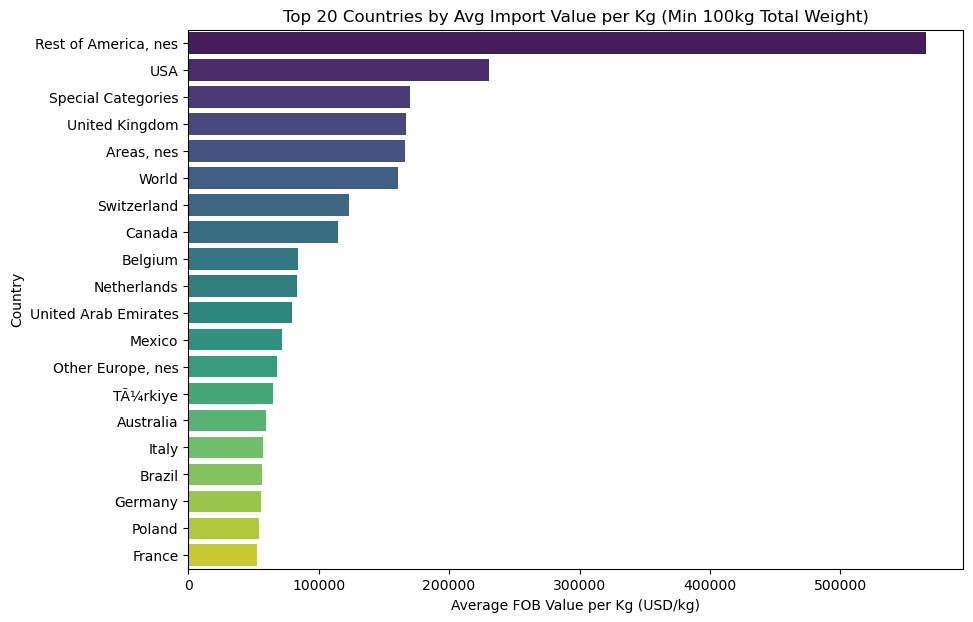

In [81]:
# Apply threshold: remove countries with too small total weight (e.g., <100kg)
filtered_df = importer_value_per_kg_df[importer_value_per_kg_df["total_netwgt"] > 100]

# Get top 20 by FOB value
top_importers_filtered = filtered_df.sort_values(by="value_per_kg", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")
plt.title("Top 20 Countries by Avg Import Value per Kg (Min 100kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.show()


Move to PBI to make a complete visualization, and conclusion. Business recommendation is in Powerpoint.

In [82]:
# Top exporters by FOB
top_exp = (df_copy_export.groupby('reporterDesc')['fobvalue']
                 .sum().sort_values(ascending=False).head(10))

# Weighted $/kg with a weight floor (e.g., 1,000 kg)
g = df_copy_export[(df_copy_export['netWgt'] > 0) & (df_copy_export['fobvalue'] > 0)] \
        .groupby('reporterDesc').agg(val=('fobvalue','sum'),
                                     wgt=('netWgt','sum'))
g['usd_per_kg'] = g['val'] / g['wgt']
price_rank = g[g['wgt'] >= 1000].sort_values('usd_per_kg', ascending=False).head(10)

x value (usd_per_kg):
reporterDesc
USA             809835.631091
Mexico          536645.204300
Canada          257213.398388
Switzerland     253111.564950
Saudi Arabia    196275.436928
India           195360.461696
Ireland         183307.160033
Australia       170653.703800
Netherlands     154861.851379
Brazil          149342.071917
Name: usd_per_kg, dtype: float64


/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2912927662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_19289/2912927662.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


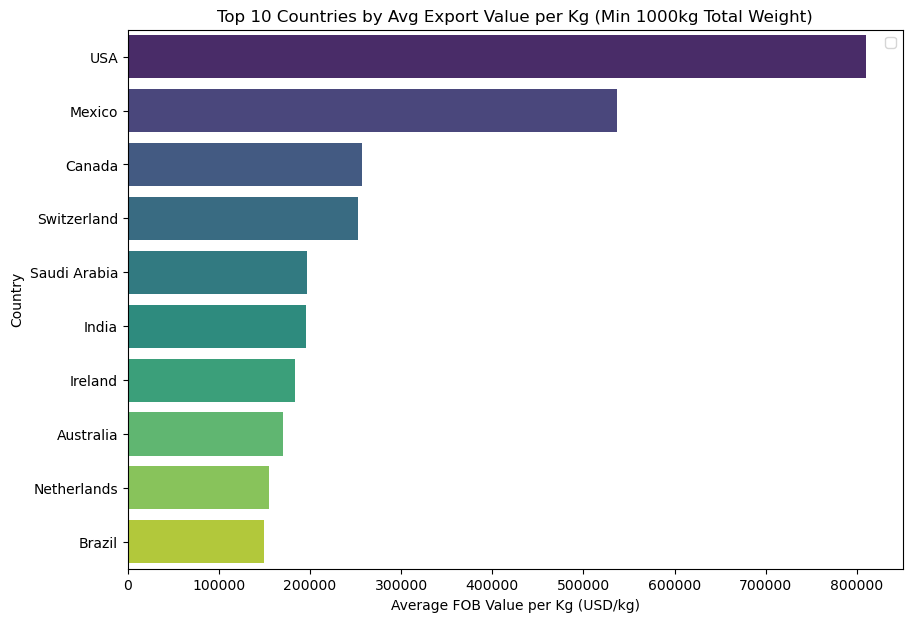

In [100]:
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
plt.title("Top 10 Countries by Avg Export Value per Kg (Min 1000kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.legend()
print("x value (usd_per_kg):")
print(price_rank['usd_per_kg'])
plt.show()